# インド株 ファクター検証 — Step 14: H-Q5 成長調整クオリティ（Profitability × Asset Growth）

**仮説**（tmp.md H-Q5）: 米国では資産成長は負のファクター（過剰投資）だが、
成長経済インドでは「高収益 × 高投資」が最良群であり、収益性で条件付けると
投資の符号が反転する。

**背景となる手元の事実**: 素の `ta_grw` は L/S −4.4%（米国型の負）、
一方 `acc_bs` は **+5.5%**（アクルーアル・アノマリー逆転）。
この不整合を「収益性条件付き」で説明できるか。

## 事前に固定する仕様

| 項目 | 仕様 |
|---|---|
| **主検定** | FM: $srtn_{t+1} = a + b_1\text{Prof} + b_2\text{Grw} + b_3(\text{Prof}\times\text{Grw}) + \text{controls} + u$ の **$b_3$**。予測符号 **+** |
| 主変数 | Prof = `gpa_act`、Grw = `ta_grw` |
| **反転確認** | Prof 上位半分 / 下位半分（月次、中立スコア > 0 / < 0）で `ta_grw` 係数を分割推計。予測: 高で **+**、低で **−** |
| スコア | Blom → sector + log(Cap) 残差。交差項 = 残差スコアの積を月次 z 化（winsor 1%） |
| コントロール | `mom12_1`, `bp_act`, `vola60`（Blom） |
| **採択ライン** | $b_3$ の NW **t > 2.5** かつ 分割推計の符号反転（高で正） |
| IS / OOS | 2008–2018 / 2019– |
| 頑健性（参考） | Prof ∈ {gpa_act, roic_act} × Grw ∈ {ta_grw, ppe_grw}、被説明変数 rtn 版、3×3 二重ソート |

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 260, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.4f}")

START, END = 200801, 202607
OOS_SPLIT = 201901
FIGDIR = "14_qgrowth"

In [2]:
FACTORS = ["gpa_act", "roic_act", "ta_grw", "ppe_grw", "mom12_1", "bp_act", "vola60"]
panel = fl.data.build_panel(FACTORS, start=START, end=END)

pieces = []
for ym in panel.index.get_level_values("yyyymm").unique():
    s = fl.data.load_forward_return(int(ym), lag=1, col="srtn")
    idx = panel.xs(ym, level="yyyymm", drop_level=False).index
    pieces.append(pd.Series(s.reindex(idx.get_level_values("bid")).to_numpy(), index=idx))
panel["fwd_srtn"] = pd.concat(pieces).reindex(panel.index)

panel = fl.preprocess.standardize_panel(panel, ["gpa_act", "roic_act", "ta_grw", "ppe_grw"],
                                        method="blom", group_col="sector",
                                        control_cols=["log_cap"], suffix="_ss")
panel = fl.preprocess.standardize_panel(panel, ["mom12_1", "bp_act", "vola60"], method="blom")


def make_interaction(p, a, b, name):
    p[f"__{name}"] = p[f"{a}_ss"] * p[f"{b}_ss"]
    p = fl.preprocess.standardize_panel(p, f"__{name}", method="zscore", winsor=0.01, suffix="_z")
    p[name] = p[f"__{name}_z"]
    return p.drop(columns=[f"__{name}", f"__{name}_z"])


for a in ("gpa_act", "roic_act"):
    for b in ("ta_grw", "ppe_grw"):
        panel = make_interaction(panel, a, b, f"x_{a}_{b}")
print("ready")

ready


## 1. 主検定: FM（srtn, lag=1）

In [3]:
Y = "fwd_srtn"
CTRL = ["mom12_1_blom", "bp_act_blom", "vola60_blom"]
_, fmA = fl.regression.fama_macbeth(panel, ["gpa_act_ss", "ta_grw_ss"], ret_col=Y)
_, fmC = fl.regression.fama_macbeth(
    panel, ["gpa_act_ss", "ta_grw_ss", "x_gpa_act_ta_grw"] + CTRL, ret_col=Y)
print("=== (A) 主効果のみ ==="); display(fmA)
print("=== (C) + 交差項 + コントロール（主検定） ==="); display(fmC)

=== (A) 主効果のみ ===


,mean,t_FM,t_NW,hit_ratio,n_months
const,0.0002,0.2955,0.2713,0.5180,222.0000
gpa_act_ss,0.0011,1.7485,1.6835,0.5676,222.0000
ta_grw_ss,-0.0019,-3.8199,-3.4359,0.3964,222.0000


=== (C) + 交差項 + コントロール（主検定） ===


,mean,t_FM,t_NW,hit_ratio,n_months
const,0.0003,0.4656,0.4221,0.5180,222.0000
gpa_act_ss,0.0008,1.3489,1.1581,0.5766,222.0000
ta_grw_ss,-0.0017,-3.7836,-3.5446,0.3964,222.0000
x_gpa_act_ta_grw,-0.0002,-0.5077,-0.5017,0.4955,222.0000
mom12_1_blom,0.0022,2.1835,2.7162,0.5946,222.0000
bp_act_blom,0.0007,0.8994,0.8058,0.5541,222.0000
vola60_blom,-0.0022,-2.7161,-2.9750,0.4324,222.0000


## 2. 反転確認: Prof 上位半分 / 下位半分での `ta_grw` 係数

In [4]:
rows = {}
for name, mask in [("High Prof (gpa_ss > 0)", panel["gpa_act_ss"] > 0),
                   ("Low Prof (gpa_ss < 0)", panel["gpa_act_ss"] < 0)]:
    sub = panel[mask]
    for y, yn in [("fwd_srtn", "srtn"), ("fwd_rtn", "rtn")]:
        _, fm = fl.regression.fama_macbeth(sub, ["ta_grw_ss"] + CTRL, ret_col=y)
        rows[(name, yn)] = {"coef_ta_grw": fm.loc["ta_grw_ss", "mean"],
                            "t_NW": fm.loc["ta_grw_ss", "t_NW"],
                            "n_months": fm.loc["ta_grw_ss", "n_months"]}
pd.DataFrame(rows).T

coef_ta_grw    t_NW  n_months
High Prof (gpa_ss > 0) srtn      -0.0019 -3.0828  222.0000
                       rtn       -0.0023 -3.5270  222.0000
Low Prof (gpa_ss < 0)  srtn      -0.0017 -2.6714  222.0000
                       rtn       -0.0021 -3.2042  222.0000

## 3. 頑健性（2×2 の交差項、srtn / rtn）

In [5]:
rows = {}
for a in ("gpa_act", "roic_act"):
    for b in ("ta_grw", "ppe_grw"):
        x = f"x_{a}_{b}"
        for y, yn in [("fwd_srtn", "srtn"), ("fwd_rtn", "rtn")]:
            _, fm = fl.regression.fama_macbeth(panel, [f"{a}_ss", f"{b}_ss", x] + CTRL, ret_col=y)
            rows[(f"{a} × {b}", yn)] = {
                "coef_interaction": fm.loc[x, "mean"], "t_NW": fm.loc[x, "t_NW"],
                "coef_grw": fm.loc[f"{b}_ss", "mean"], "t_grw": fm.loc[f"{b}_ss", "t_NW"]}
pd.DataFrame(rows).T

coef_interaction    t_NW  coef_grw   t_grw
gpa_act × ta_grw   srtn           -0.0002 -0.5017   -0.0017 -3.5446
                   rtn            -0.0004 -0.7334   -0.0021 -4.3022
gpa_act × ppe_grw  srtn           -0.0011 -2.1757   -0.0012 -2.2820
                   rtn            -0.0012 -2.5459   -0.0014 -2.5792
roic_act × ta_grw  srtn           -0.0004 -0.9074   -0.0016 -3.4935
                   rtn            -0.0006 -1.2447   -0.0020 -4.2836
roic_act × ppe_grw srtn           -0.0009 -1.5884   -0.0008 -1.6359
                   rtn            -0.0010 -1.9011   -0.0012 -2.1068

## 4. IS / OOS と係数の累積

,mean_coef,t_NW,hit_ratio,n_months
IS 2008-2018,0.0001,0.2038,0.5227,132.0000
OOS 2019-,-0.0008,-1.0544,0.4556,90.0000


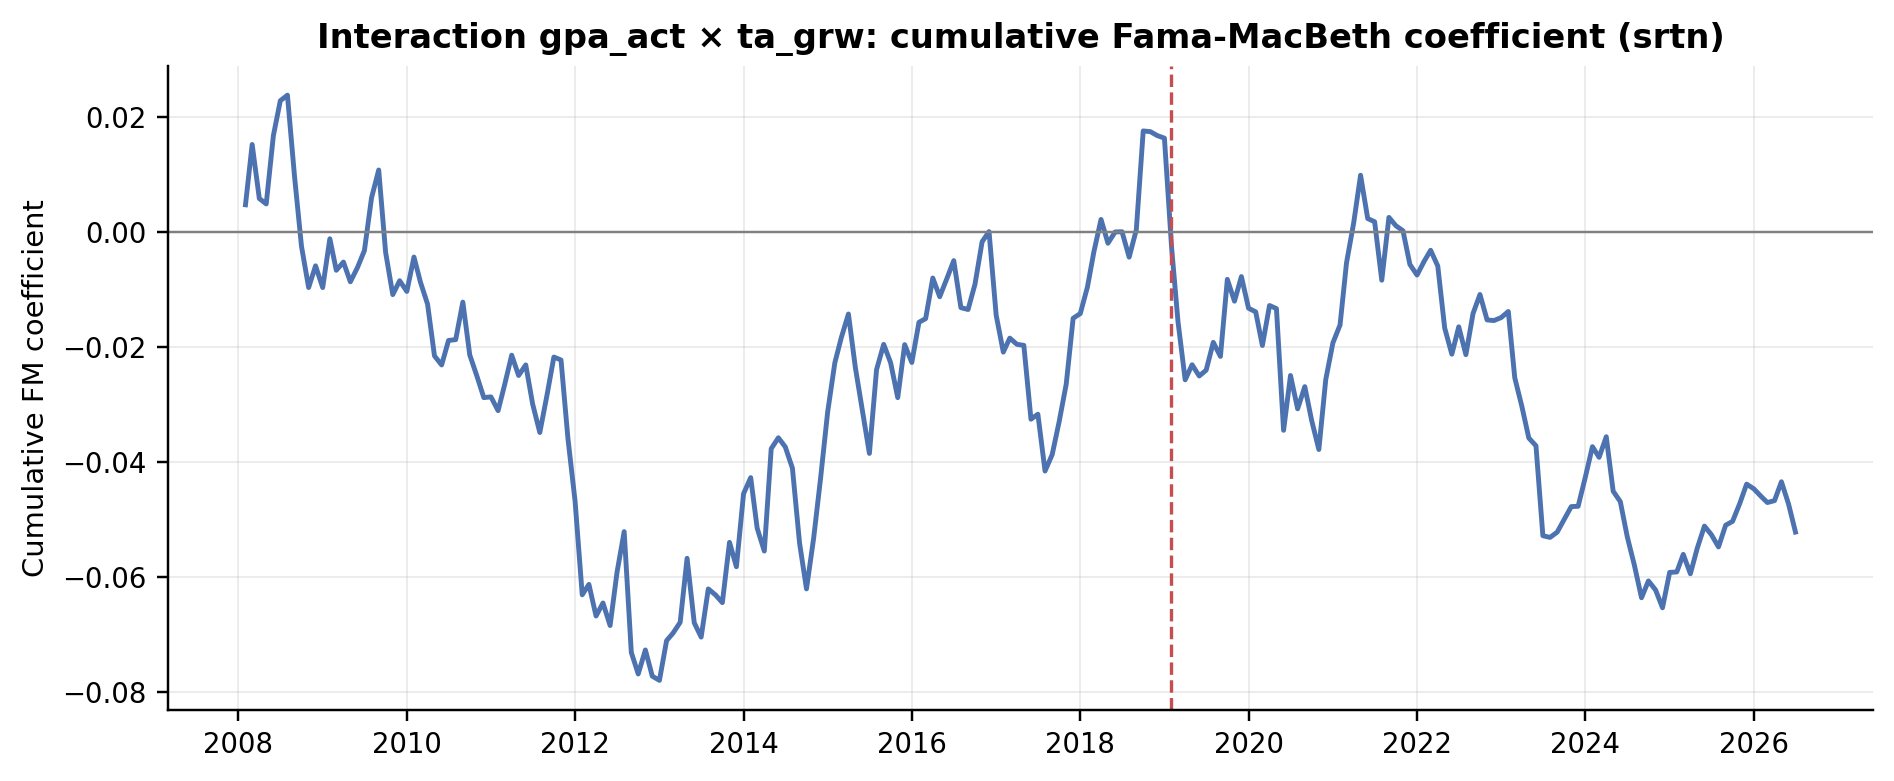

In [6]:
coefs, _ = fl.regression.fama_macbeth(
    panel, ["gpa_act_ss", "ta_grw_ss", "x_gpa_act_ta_grw"] + CTRL, ret_col=Y)
x = "x_gpa_act_ta_grw"
rows = {}
for name, mask in [("IS 2008-2018", coefs.index < OOS_SPLIT),
                   ("OOS 2019-", coefs.index >= OOS_SPLIT)]:
    sub = coefs.loc[mask, x]
    rows[name] = {"mean_coef": sub.mean(), "t_NW": fl.metrics.newey_west_tstat(sub),
                  "hit_ratio": float((sub > 0).mean()), "n_months": len(sub)}
display(pd.DataFrame(rows).T)

fig, ax = plt.subplots(figsize=(10, 3.8))
xx = fl.plotting.to_datetime_index(coefs.index)
ax.plot(xx, coefs[x].cumsum(), color="#4C72B0", linewidth=1.6)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(pd.Timestamp("2019-01-31"), color="#C44E52", linestyle="--", linewidth=1.1)
ax.set_ylabel("Cumulative FM coefficient")
ax.set_title("Interaction gpa_act × ta_grw: cumulative Fama-MacBeth coefficient (srtn)")
fl.plotting.savefig(fig, f"{FIGDIR}/98_interaction_cumcoef");

## 5. 二重ソート（Prof 3分位 × Growth 3分位、EW 対ベンチ超過・算術年率）

仮説どおりなら「Prof T3 行では Growth T3 が最良、Prof T1 行では Growth T3 が最悪」。

In [7]:
p3 = fl.quantile.assign_quantiles(panel, "gpa_act_ss", q=3, out_col="p3")
g3 = fl.quantile.assign_quantiles(panel, "ta_grw_ss", q=3, out_col="g3")
df = panel.assign(p3=p3, g3=g3).dropna(subset=["p3", "g3", "fwd_rtn"])
bench = panel[panel["in_bench"]].groupby(level="yyyymm")["fwd_rtn"].mean()

cell = df.groupby([df.index.get_level_values("yyyymm"), "p3", "g3"])["fwd_rtn"].mean().unstack(["p3", "g3"])
cell = cell.sub(bench, axis=0)

tbl = (cell.mean() * 12).unstack("g3") * 100
tbl.index = [f"Prof T{int(i)}" for i in tbl.index]
tbl.columns = [f"Growth T{int(c)}" for c in tbl.columns]
tbl["T3-T1 (growth spread)"] = tbl["Growth T3"] - tbl["Growth T1"]
print("EW 対ベンチ超過（算術年率, %）:")
display(tbl.round(2))

hi = (cell[(3.0, 3.0)] - cell[(3.0, 1.0)]).dropna()
lo = (cell[(1.0, 3.0)] - cell[(1.0, 1.0)]).dropna()
dd = (hi - lo).dropna()
pd.DataFrame({
    "高Prof内 Growthスプレッド": fl.metrics.summarize(hi),
    "低Prof内 Growthスプレッド": fl.metrics.summarize(lo),
    "差の差（交差の検定）": fl.metrics.summarize(dd),
}).T[["ann_return", "IR", "t_stat_NW", "hit_ratio"]]

EW 対ベンチ超過（算術年率, %）:


,Growth T1,Growth T2,Growth T3,T3-T1 (growth spread)
Prof T1,0.5800,-1.6200,-6.5600,-7.1400
Prof T2,4.0300,-1.0700,-0.4200,-4.4600
Prof T3,6.9300,3.2300,-0.7300,-7.6500


,ann_return,IR,t_stat_NW,hit_ratio
高Prof内 Growthスプレッド,-0.0794,-0.7276,-2.4466,0.4234
低Prof内 Growthスプレッド,-0.0742,-0.7101,-3.0170,0.4189
差の差（交差の検定）,-0.0149,-0.1063,-0.1342,0.5405


---

## 判定基準（再掲）

- **採択**: (C) の交差項 NW t > 2.5、かつ分割推計で高 Prof 群の `ta_grw` 係数が正
- 交差が非有意でも「高 Prof 群で係数が有意に負でない（= 米国型の一律ペナルティが不適切）」
  なら、Growth の扱いを条件付きにする弱い根拠にはなる